In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import os
from dotenv import load_dotenv
from pathlib import Path
import cv2
import numpy as np

load_dotenv()
data_pth = Path(os.getenv("DATA_PATH", "data"))
train_csv_pth = f"{data_pth}/train.csv"
train_img_pth = Path(f"{data_pth}/train_images")

In [3]:
train_csv = pd.read_csv(train_csv_pth)
train_csv = train_csv.copy()

classid = train_csv["ClassId"]
class_count = classid.value_counts()

In [ ]:
train_csv.head()

In [ ]:
plt.bar(class_count.index, class_count)
plt.show()

In [ ]:
imageid = train_csv["ImageId"].value_counts().reset_index(name="no._of_defect")
imageid

In [4]:
single_defect = ["0002cc93b.jpg", "060964105.jpg", "0576d3847.jpg", "052cc2a0f.jpg"]

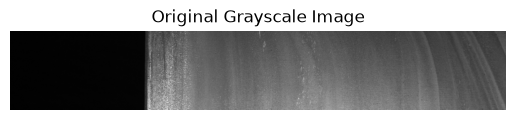

Calculated Otsu threshold value: 51.0


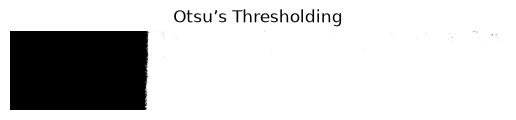

In [9]:
image = cv2.imread(f"{data_pth}/train_images/{single_defect[1]}")
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


def show_image(img, title):
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()


show_image(gray_image, "Original Grayscale Image")

ret, otsu_thresh = cv2.threshold(
    gray_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
print("Calculated Otsu threshold value:", ret)
show_image(otsu_thresh, "Otsu’s Thresholding")

In [ ]:
show_image(gray_image, "Original Grayscale Image")